In [1]:
from sqlalchemy import create_engine
import pandas as pd
import logging
from pathlib import Path

# 配置日志
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

def get_chat_data(db_path):
    """
    获取chat表的所有数据并转换为DataFrame
    
    Args:
        db_path (str): 数据库文件路径
    
    Returns:
        pd.DataFrame: 包含chat表数据的DataFrame
    """
    try:
        # 创建数据库连接
        engine = create_engine(f'sqlite:///{db_path}')
        
        # 读取chat表数据
        query = """ 
        select a.*,b.name
        from (
        SELECT * from feedback) a 
        left join (
        select id,name from user 
        ) b
        on a.user_id=b.id;
        """
        df = pd.read_sql_query(query, engine)
        
        logger.info(f"成功读取chat表数据，共 {len(df)} 条记录")
        return df
        
    except Exception as e:
        logger.error(f"读取chat表数据时出错: {str(e)}")
        raise

if __name__ == "__main__":
    # 数据库文件路径
    db_path = "../backend/data/webui.db"
    
    # 获取数据
    chat_df = get_chat_data(db_path)
    
    # 显示数据基本信息
    print("\n数据基本信息:")
    print(chat_df.info())
    
    # 显示前几行数据
    print("\n数据预览:")
    print(chat_df.head())
    
    # 显示数据统计信息
    print("\n数据统计信息:")
    print(chat_df.describe()) 

2025-07-02 22:55:16,335 - INFO - 成功读取chat表数据，共 242 条记录



数据基本信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          242 non-null    object
 1   user_id     242 non-null    object
 2   version     242 non-null    int64 
 3   type        242 non-null    object
 4   data        242 non-null    object
 5   meta        242 non-null    object
 6   snapshot    242 non-null    object
 7   created_at  242 non-null    int64 
 8   updated_at  242 non-null    int64 
 9   name        242 non-null    object
dtypes: int64(3), object(7)
memory usage: 19.0+ KB
None

数据预览:
                                     id                               user_id  \
0  fa428607-ec04-4589-ac17-409a025042b3  8d7e1db7-c386-46f1-96a2-d5f71ffe11ca   
1  190d61e6-1b7c-4cf5-a006-b5888cd0674f  8d7e1db7-c386-46f1-96a2-d5f71ffe11ca   
2  be9c4313-a040-4f61-9aa1-028399117403  8d7e1db7-c386-46f1-96a2-d5f71ffe11ca   
3  6d648b62-1ffa-40

In [29]:
chat_df.snapshot[0]

'{"chat": {"id": "905a46d5-f70e-4f8c-9f7d-60e70a906d9c", "user_id": "8d7e1db7-c386-46f1-96a2-d5f71ffe11ca", "title": "\\ud83d\\udc4b \\u95ee\\u5019\\u4e0e\\u5e2e\\u52a9", "chat": {"id": "", "title": "\\ud83d\\udc4b \\u95ee\\u5019\\u4e0e\\u5e2e\\u52a9", "models": ["deepseek-r1-250120"], "params": {}, "history": {"messages": {"79918bb1-5008-4892-a206-87776a98cfe2": {"id": "79918bb1-5008-4892-a206-87776a98cfe2", "parentId": null, "childrenIds": ["39ea7b20-f11a-487f-b0b2-844e2bf75b9d"], "role": "user", "content": "\\u4f60\\u597d", "timestamp": 1747142801, "models": ["deepseek-r1-250120"]}, "39ea7b20-f11a-487f-b0b2-844e2bf75b9d": {"parentId": "79918bb1-5008-4892-a206-87776a98cfe2", "id": "39ea7b20-f11a-487f-b0b2-844e2bf75b9d", "childrenIds": ["6ca31b15-bdb0-4b64-83c5-a801b44cc327"], "role": "assistant", "content": "<details type=\\"reasoning\\" done=\\"true\\" duration=\\"6\\">\\n<summary>Thought for 6 seconds</summary>\\n> \\u55ef\\uff0c\\u7528\\u6237\\u53d1\\u6765\\u4e86\\u201c\\u4f60\\u5

In [2]:
feedback_data=[]
import json
for i,r in chat_df.iterrows():
    feedback_id = r['id']
    snapshot = json.loads(r['snapshot'])
    data=json.loads(r['data'])
    rating = data.get("rating",-99)
    rating_score = data.get("details",{}).get("rating",-99)
    rating_comment = data.get("comment","")
    if rating == -1:
        rating = "bad"
    elif rating == 1:
        rating = "good"
    else:
        rating = "unknown"

    name= r['name']
    user_id=r['user_id']
    meta=json.loads(r['meta'])
    message_id = meta.get("message_index")
    query = feedback_message = snapshot['chat']['chat']['messages'][message_id-2]['content']
    feedback_message = snapshot['chat']['chat']['messages'][message_id-1]
    feedback_message_content = feedback_message['content']
    if name in ['dali','cz',' cz']:
        continue
    # history = snapshot.get("history",{})
    feedback_data.append({
        "feedback_id":feedback_id,
        "user_id":user_id,
        "name":name,
        "goog_or_bad":rating,
        "rating_score":rating_score,
        "rating_comment":rating_comment,
        "query":query,
        "answer":feedback_message_content,
        "meta":meta,
        "data":data,
        "feedback_all_message":feedback_message,
        "snapshot":snapshot
    })

print("feedback_data",len(feedback_data))
feedback_data[0]

feedback_data 232


{'feedback_id': 'b389bd73-78ae-4aa7-9fa6-4ee6aef03df5',
 'user_id': 'bf27aabe-3100-4283-a90e-4edc55baf261',
 'name': 'xuchengba',
 'goog_or_bad': 'good',
 'rating_score': -99,
 'rating_comment': None,
 'query': '如何输入多少',
 'answer': '>\n\n<details type="reasoning" done="true" duration="9">\n<summary>Thought for 9 seconds</summary>\n> 好的，我现在需要回答用户的问题：“如何输入多少”。首先，我要根据提供的康复师X教学内容概述和内部搜索引擎返回的内容来构建答案。\n> \n> 首先，查看康复师X的教学内容，特别是关于形容词输入的部分。在L4阶段，形容词如“多少”属于需要教授的内容。根据教学内容，输入形容词需要通过对比和多样本来帮助孩子提取特征，并且要结合有意义的生活场景，让孩子理解其功能和应用。\n> \n> 接下来，查看内部搜索引擎返回的内容。例如，文档[1]提到通过选择疑问句，如“你要喝多的还是少的？”，并加大两者的差异，让孩子在强烈对比中理解多少的概念。同时，文档[11]和[27]也讨论了使用实际生活中的情境，如倒饮料时明显区分多和少，或者通过食物量的不同来输入概念。\n> \n> 需要注意以下几点：\n> 1. **使用选择疑问句**：初期用差距大的选项，如多的一杯和少的几滴，帮助孩子明确选择。\n> 2. **实际体验**：让孩子在需要时体验多少带来的结果差异，例如多倒奶粉让饮料更浓，少倒则淡，从而理解多少的实际影响。\n> 3. **避免复杂化**：不要追求孩子多说，保持输入简洁，重点在听懂而非表达。\n> 4. **结合强化物**：利用孩子喜欢的食物或活动，制造需求场景，如吃糖时选择多或少，增强动机。\n> \n> 此外，文档[33]强调样本的阶段需与孩子能力匹配，从直观对比到意义样本，逐步深入。例如，初期用明显差异的样本，后期引入功能性场景，如泡奶粉时的量影响口感。\n> \n> 最后，确保回答符合康复师X的分层要求，特别是L

In [77]:
feedback_data[0]['snapshot']['chat']['chat']['messages'][3]

{'parentId': '6ca31b15-bdb0-4b64-83c5-a801b44cc327',
 'id': '1413a430-50be-4c4b-b31b-d46c98a11630',
 'childrenIds': [],
 'role': 'assistant',
 'content': '<details type="reasoning" done="true" duration="12">\n<summary>Thought for 12 seconds</summary>\n> 好的，用户问今天是星期几，我需要提供准确的回答。首先，我要确认自己是否有访问实时信息的能力。不过，根据之前的设定，我不能联网，所以无法获取实时数据。这时候应该怎么处理呢？\n> \n> 用户之前已经问过类似的问题，我之前回复说无法提供实时信息，并建议他们查看设备上的日期。这次用户又问同样的问题，可能他们确实需要知道今天的星期几，但可能没有其他设备可用，或者希望在这里直接得到答案。\n> \n> 我需要保持一致性，不能这次突然给出不同的回应。但可能用户期望不同的回答，或者他们可能没注意到之前的说明。这时候应该再次礼貌地说明无法提供实时信息，并重复建议他们查看手机或电脑的设置。\n> \n> 另外，用户用中文提问，可能不太熟悉如何查看日期，或者需要更详细的指引。是否需要提供更具体的步骤，比如如何查看手机上的日期？比如，告诉他们下拉通知栏或者打开日历应用？\n> \n> 不过，之前的回复已经比较简洁，可能用户已经知道方法，只是希望在这里直接得到答案。但受限于功能，我无法做到。这时候可能需要再次表达歉意，并明确说明限制，避免用户再次询问同样的问题。\n> \n> 需要确保回复友好且有帮助，即使无法直接回答问题。可以加上表情符号，让语气更亲切。例如再次用🙂，保持一致的风格。\n> \n> 总结回复要点：无法提供实时信息，建议查看设备日期，表达歉意，保持友好。结构要清晰，避免冗长，让用户容易理解。\n</details>\n您好，我无法访问实时信息，因此无法告知您今天是星期几。建议您查看手机、电脑或其他设备上的日期功能来获取准确信息。谢谢理解！🙂',
 'model': 'deepseek-r1-250120',
 'modelName': 'deepseek-r1-250120

In [4]:
import pandas as pd
chat_data_pd=pd.DataFrame(feedback_data)
chat_data_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232 entries, 0 to 231
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   feedback_id           232 non-null    object 
 1   user_id               232 non-null    object 
 2   name                  232 non-null    object 
 3   goog_or_bad           232 non-null    object 
 4   rating_score          231 non-null    float64
 5   rating_comment        101 non-null    object 
 6   query                 232 non-null    object 
 7   answer                232 non-null    object 
 8   meta                  232 non-null    object 
 9   data                  232 non-null    object 
 10  feedback_all_message  232 non-null    object 
 11  snapshot              232 non-null    object 
dtypes: float64(1), object(11)
memory usage: 21.9+ KB


In [6]:
chat_data_pd.goog_or_bad.value_counts()

goog_or_bad
good    152
bad      80
Name: count, dtype: int64

In [115]:
chat_data_pd.to_excel("data/feedback_data_20250615_3.xlsx",index=False)

In [113]:
chat_data_pd.groupby("name")['feedback_id'].count()

name
ganglii       3
xuchengba     2
呼呼huhu～      16
地瓜妈          51
宋园梦           3
康复师X壹壹妈       6
杨老师           4
Name: feedback_id, dtype: int64

In [112]:
chat_data_score.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33 entries, 0 to 92
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   feedback_id           33 non-null     object 
 1   user_id               33 non-null     object 
 2   name                  33 non-null     object 
 3   goog_or_bad           33 non-null     object 
 4   rating_score          33 non-null     float64
 5   rating_comment        33 non-null     object 
 6   query                 33 non-null     object 
 7   answer                33 non-null     object 
 8   meta                  33 non-null     object 
 9   data                  33 non-null     object 
 10  feedback_all_message  33 non-null     object 
 11  snapshot              33 non-null     object 
dtypes: float64(1), object(11)
memory usage: 3.4+ KB


In [99]:
chat_data_score=chat_data_pd[chat_data_pd.rating_score>0]
chat_data_score.info()
chat_data_score.rating_score.mean()


<class 'pandas.core.frame.DataFrame'>
Index: 33 entries, 0 to 92
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   feedback_id           33 non-null     object 
 1   user_id               33 non-null     object 
 2   name                  33 non-null     object 
 3   goog_or_bad           33 non-null     object 
 4   rating_score          33 non-null     float64
 5   rating_comment        33 non-null     object 
 6   query                 33 non-null     object 
 7   answer                33 non-null     object 
 8   meta                  33 non-null     object 
 9   data                  33 non-null     object 
 10  feedback_all_message  33 non-null     object 
 11  snapshot              33 non-null     object 
dtypes: float64(1), object(11)
memory usage: 3.4+ KB


5.2727272727272725

array([[<Axes: title={'center': 'rating_score'}>]], dtype=object)

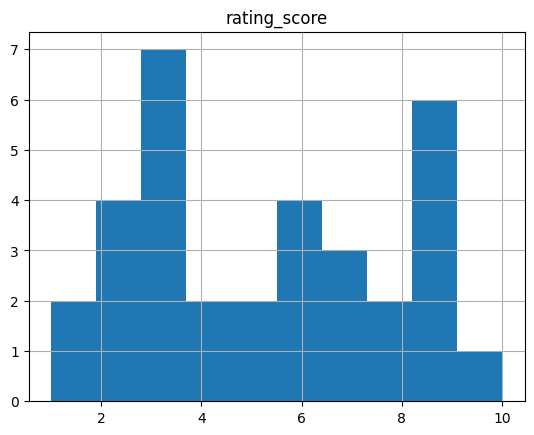

In [95]:
chat_data_score.hist()

feedback_id             10.555556
name                    10.555556
goog_or_bad             10.555556
rating_score            10.222222
rating_comment           4.000000
query                   10.555556
answer                  10.555556
meta                    10.555556
data                    10.555556
feedback_all_message    10.555556
snapshot                10.555556
dtype: float64